<a href="https://colab.research.google.com/github/ARehman007-max/C-.projects/blob/main/Copy_of_DNA_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# Map cluster labels to original labels
# Since K-Means doesn't assign the same labels as the target, we need to map them
label_mapping = {}
for i in range(3):
    mask = (cluster_labels == i)
    label_mapping[i] = np.bincount(y[mask]).argmax()

# Apply the mapping to the cluster labels
mapped_labels = np.vectorize(label_mapping.get)(cluster_labels)

# Evaluate the clustering performance
accuracy = accuracy_score(y, mapped_labels)
conf_matrix = confusion_matrix(y, mapped_labels)

# Print the results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)

# Visualize the clustering
df = pd.DataFrame(X_scaled, columns=feature_names)
df['Cluster'] = cluster_labels
df['Species'] = y

sns.pairplot(df, hue='Cluster', markers=["o", "s", "D"])
plt.suptitle("K-Means Clustering of Iris Dataset", y=1.02)
plt.show()


Load the Iris Dataset

In [ ]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create a DataFrame for easy manipulation
df = pd.DataFrame(X, columns=feature_names)
df['Species'] = y
df['Species'] = df['Species'].map({i: target_names[i] for i in range(len(target_names))})

print("First 5 rows of the Iris dataset:")
print(df.head())


First 5 rows of the Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


Standardize the Dataset

In [ ]:
# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of the standardized dataset:")
print(pd.DataFrame(X_scaled, columns=feature_names).head())



First 5 rows of the standardized dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


Apply K-Means Clustering

In [ ]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# Add cluster labels to the DataFrame
df['Cluster'] = cluster_labels


Map Cluster Labels to Original Labels

In [ ]:
# Map cluster labels to original labels
label_mapping = {}
for i in range(3):
    mask = (cluster_labels == i)
    label_mapping[i] = np.bincount(y[mask]).argmax()

# Apply the mapping to the cluster labels
mapped_labels = np.vectorize(label_mapping.get)(cluster_labels)

print("\nCluster to Species Mapping:")
for cluster, species in label_mapping.items():
    print(f"Cluster {cluster} -> {target_names[species]}")

# Add mapped labels to the DataFrame for comparison
df['Mapped_Labels'] = mapped_labels
df['Mapped_Species'] = df['Mapped_Labels'].map({i: target_names[i] for i in range(len(target_names))})



Cluster to Species Mapping:
Cluster 0 -> virginica
Cluster 1 -> setosa
Cluster 2 -> versicolor


Evaluate the Clustering Performance


Accuracy of K-Means Clustering for Classification: 83.33%

Confusion Matrix:
[[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]


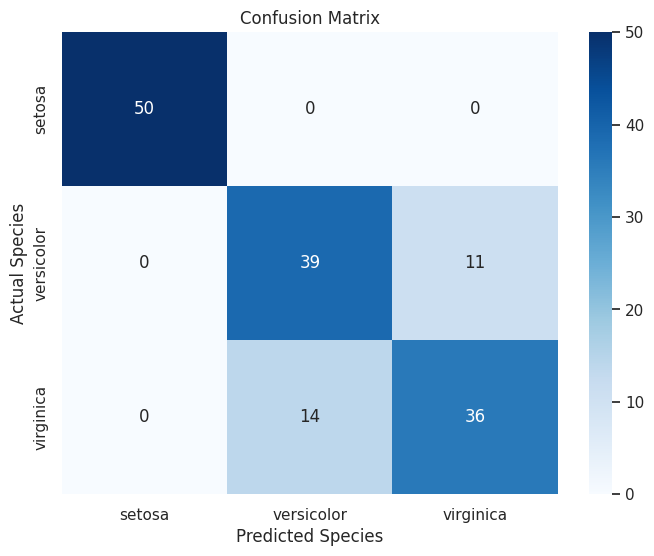

In [ ]:
# Evaluate the clustering performance
accuracy = accuracy_score(y, mapped_labels)
conf_matrix = confusion_matrix(y, mapped_labels)

print("\nAccuracy of K-Means Clustering for Classification: {:.2f}%".format(accuracy * 100))
print("\nConfusion Matrix:")
print(conf_matrix)

# Convert confusion matrix to DataFrame for better visualization
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.show()


Visualize the Clustering

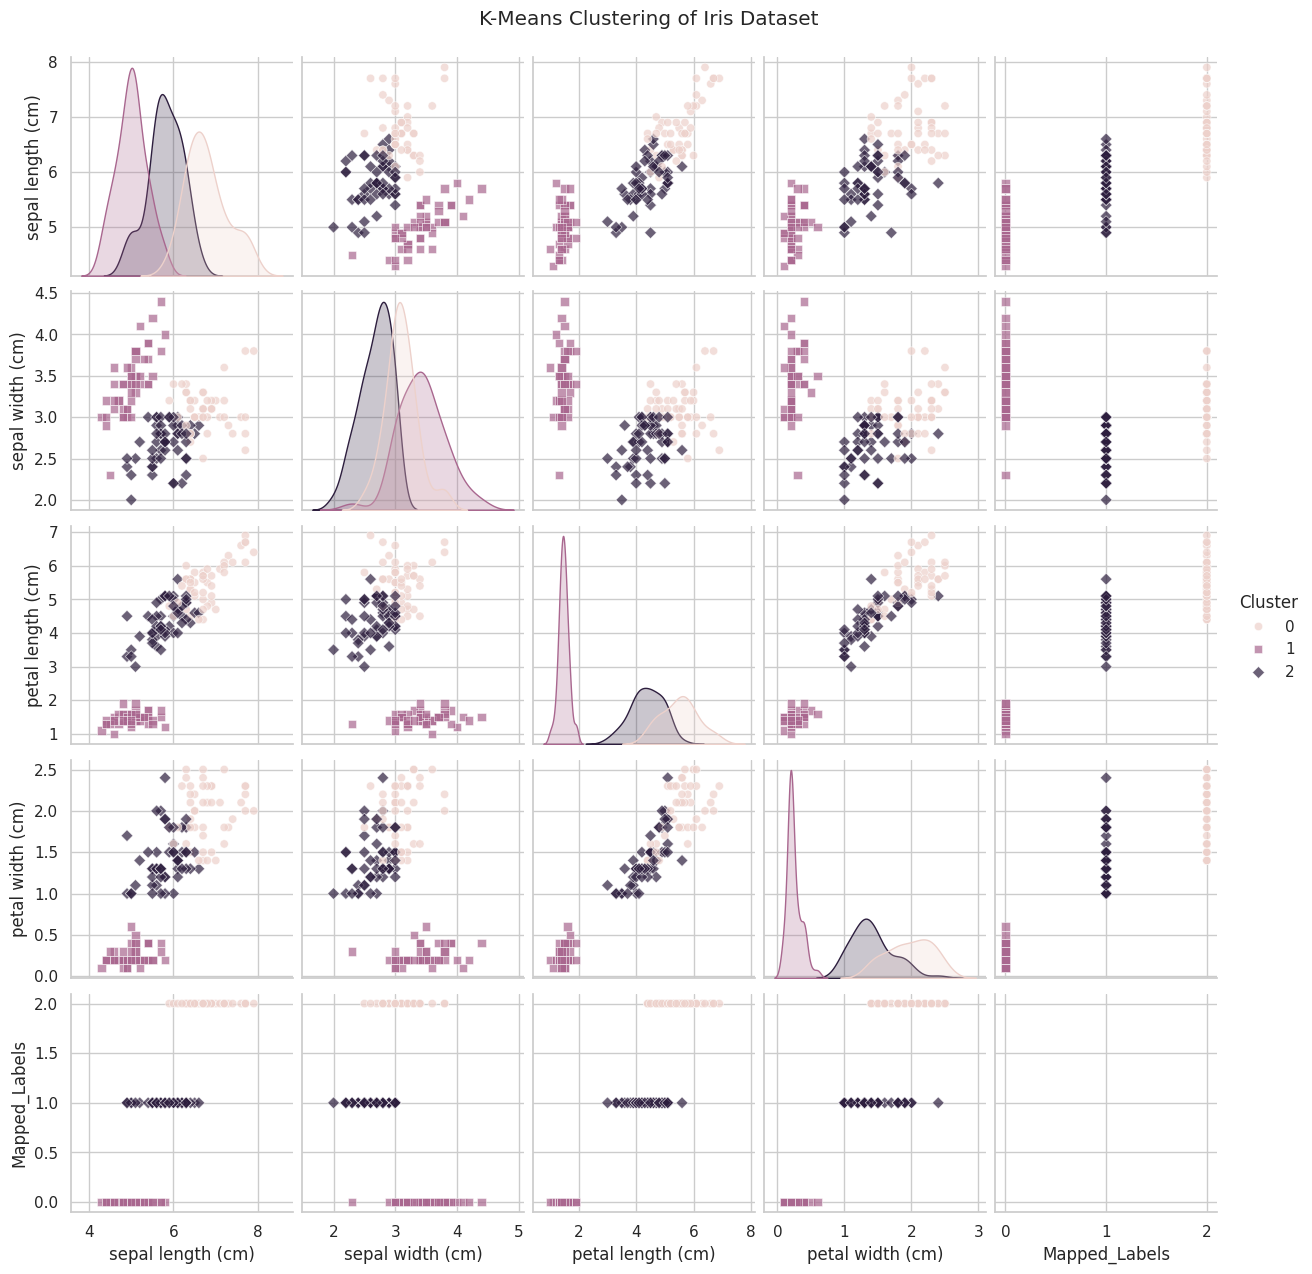

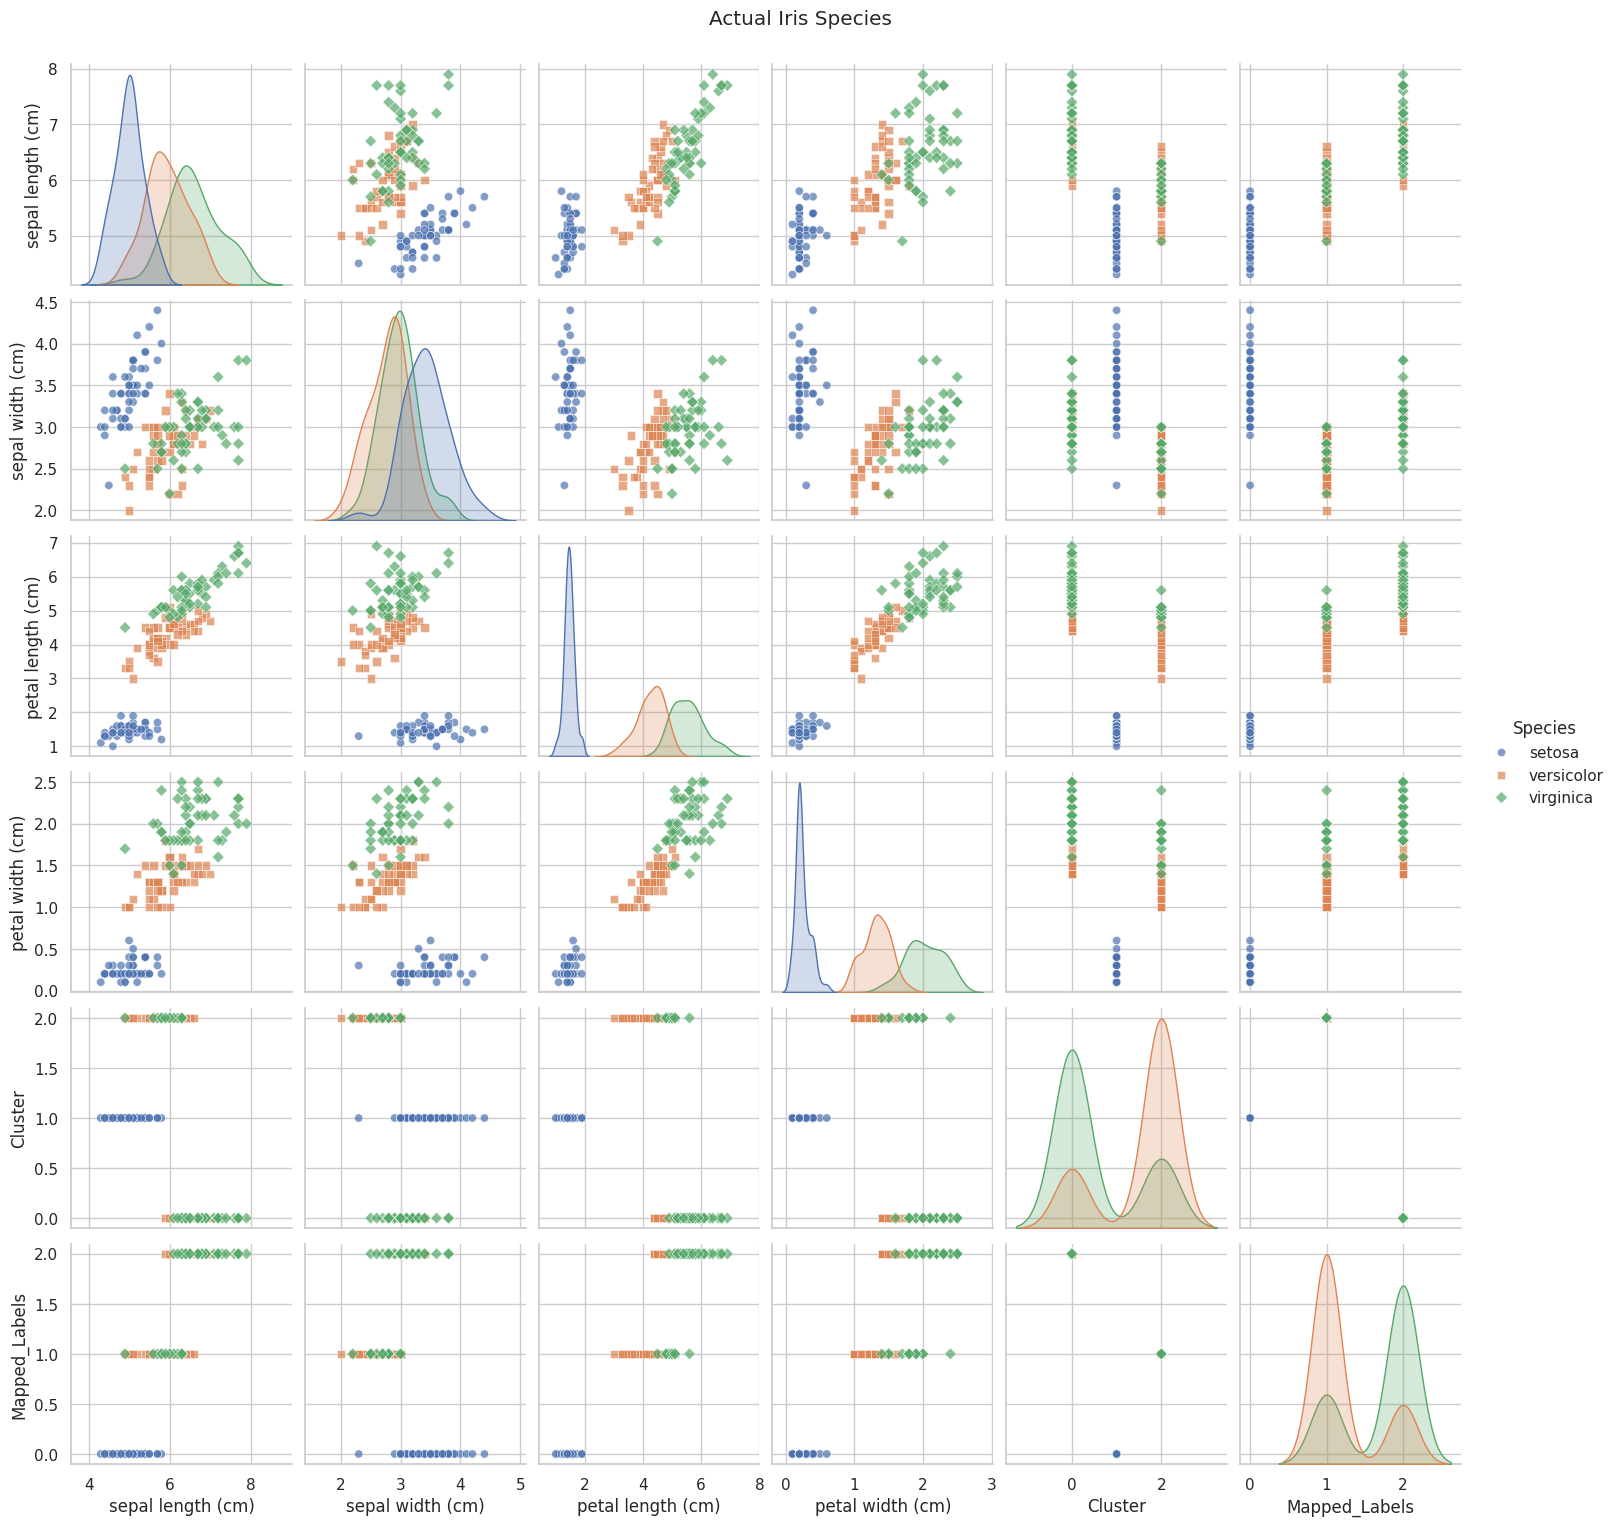

In [ ]:
# Visualize the clustering
sns.pairplot(df, hue='Cluster', markers=["o", "s", "D"], plot_kws={'alpha':0.7})
plt.suptitle("K-Means Clustering of Iris Dataset", y=1.02)

# Plot pairplot for original species
sns.pairplot(df, hue='Species', markers=["o", "s", "D"], plot_kws={'alpha':0.7})
plt.suptitle("Actual Iris Species", y=1.02)

plt.show()
